# 03 Modelo Clasíficación Ticket Alto

Este notebook usa la base `EDA`, entrena una `Regresión Logística`, genera predicciones y exporta el `Parquet` final de clasificación.


## 1. Librerías


In [1]:
# Manejo de rutas internas del proyecto.
from pathlib import Path
# Guardado de listas de variables en formato JSON.
import json

# Persistencia del modelo entrenado.
import joblib
# Manejo tabular de la base de clasificación.
import pandas as pd
# Gráficas generales del modelo.
import matplotlib.pyplot as plt
# Visualizaciones estadísticas para probabilidades y distribuciones.
import seaborn as sns
# Preprocesamiento por tipo de columna.
from sklearn.compose import ColumnTransformer
# Relleno de valores faltantes si se llegaran a presentar.
from sklearn.impute import SimpleImputer
# Modelo de clasificación elegido para ticket alto.
from sklearn.linear_model import LogisticRegression
# Métricas principales de clasificación.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# Gráficas de matriz de confusion y curva ROC.
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
# Particion de entrenamiento y prueba.
from sklearn.model_selection import train_test_split
# Construcción del flujo completo de transformación y modelo.
from sklearn.pipeline import Pipeline
# Codificacion de variables categoricas y escalamiento numerico.
from sklearn.preprocessing import OneHotEncoder, StandardScaler


### Para qué se usan estas librerías

- `Path`: localizar la raíz del proyecto y construir rutas de entrada, salida y guardado del modelo.
- `json`: guardar la lista final de variables utilizadas por el modelo.
- `joblib`: exportar el modelo ya entrenado para retilizarlo.
- `pandas`: leer la base `EDA`, preparar tablas de métricas y construir la salida final.
- `matplotlib` y `seaborn`: generar visualizaciones de apoyo para revisar el comportamiento del modelo.
- `ColumnTransformer`, `Pipeline`, `OneHotEncoder`, `StandardScaler` y `SimpleImputer`: preparar las variables antes del entrenamiento.
- `LogisticRegression`: entrenar el modelo de clasificación de `ticket_alto`.
- métricas de `sklearn`: medir aciertos, errores y capacidad de separación del modelo.


## 2. Definír rutas


### Nota sobre nombres técnicos

En el código y en las columnas técnicas se usa `anio` en lugar de `año`. La letra `ñ` se deja solo en el texto explicativo, pero no en nombres de variables, columnas o archivos para evitar caracteres especiales y mantener compatibilidad.


In [2]:
from pathlib import Path

def resolve_project_root() -> Path:
    # Buscar la raíz del proyecto a partir del directorio actual.
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "parquets").exists():
            return candidate
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto")

PROJECT_ROOT = resolve_project_root()

# Definír las rutas de entrada y salida de la etapa 03.
INPUT_PATH = PROJECT_ROOT / "parquets" / "02_EDA_Base_Tickets" / "02_base_eda_tickets.parquet"
OUTPUT_DIR = PROJECT_ROOT / "parquets" / "03_Modelo_Clasificacion_Ticket_Alto"
OUTPUT_PATH = OUTPUT_DIR / "03_tickets_clasificados.parquet"
MODEL_DIR = PROJECT_ROOT / "models" / "03_Modelo_Clasificacion_Ticket_Alto"
MODEL_PATH = MODEL_DIR / "03_modelo_regresion_logistica.joblib"
FEATURES_PATH = MODEL_DIR / "03_features_regresion_logistica.json"

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Parquet de entrada: {INPUT_PATH}")
print(f"Parquet de salida: {OUTPUT_PATH}")
print(f"Modelo entrenado: {MODEL_PATH}")


Raiz del proyecto: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning
Parquet de entrada: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\02_EDA_Base_Tickets\02_base_eda_tickets.parquet
Parquet de salida: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\03_Modelo_Clasificacion_Ticket_Alto\03_tickets_clasificados.parquet
Modelo entrenado: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\03_Modelo_Clasificacion_Ticket_Alto\03_modelo_regresion_logistica.joblib


## 3. Cargar la base EDA


In [3]:
# Leer la base EDA de entrada.
df = pd.read_parquet(INPUT_PATH)

# Mostrar las primeras filas de la base para clasificación.
df.head()


,id_ticket_modelado,fecha,anio_mes,dia,mes,nombre_mes,trimestre,anio,dia_semana,dia_tipo,...,residuo_abs_subtotal_total,residuo_pago_total,ticket_consistente_subtotal,ticket_consistente_pago,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte,ticket_alto,rango_total_pedido
0,1,2024-01-02,2024-01,2,1,Enero,1,2024,Martes,Entre semana,...,695.0,0.0,0,1,0,0,0,1,0,Bajo
1,2,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,3580.0,0.0,0,1,1,1,1,1,0,Bajo
2,3,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,4750.0,0.0,0,1,1,1,1,1,0,Medio
3,4,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,1115.0,-65.0,0,0,1,0,0,1,0,Medio
4,5,2024-01-03,2024-01,3,1,Enero,1,2024,Miércoles,Entre semana,...,125.0,0.0,0,1,0,0,0,1,0,Medio


### Resultado

La base `EDA` se cargo correctamente desde `02_base_eda_tickets.parquet`.

La vista previa muestra `5 filas x 43 columnas`, lo que confirma que el modelo de clasificación parte de una base ya enriquecida con variables exploratorias.

En esta etapa ya se observan campos útiles para clasificar tickets, como:

- `anio_mes`
- `dia_tipo`
- `residuo_pago_total`
- `ticket_consistente_pago`
- `ticket_alto`
- `rango_total_pedido`

En los nombres técnicos se mantiene `anio` sin `ñ` por compatibilidad con columnas, archivos y artefactos del modelo.


## 4. Seleccionar variables y target


In [4]:
# Definír las variables explicativas del modelo.
# Se combinan variables de calendario, sucursal, empleado, mesa, pago y composicion del ticket.
# Los nombres técnicos se mantienen sin acentos ni  para conservar compatibilidad.
FEATURES = [
    "dia", "mes", "trimestre", "dia_semana", "dia_tipo", "fin_semana",
    "ciudad", "capacidad_sucursal", "tipo_empleado", "salario", "turno",
    "numero_mesa", "capacidad_mesa", "metodo_pago", "lineas_ticket",
    "cantidad_total", "platillos_distintos", "categorias_distintas",
    "incluye_bebida", "incluye_postre", "incluye_entrada", "incluye_platillo_fuerte"
]

# Definír la variable objetivo.
TARGET = "ticket_alto"

# Separar la matriz de entrada y la serie objetivo para el entrenamiento.
X = df[FEATURES].copy()
y = df[TARGET].copy()
X.head()


,dia,mes,trimestre,dia_semana,dia_tipo,fin_semana,ciudad,capacidad_sucursal,tipo_empleado,salario,...,capacidad_mesa,metodo_pago,lineas_ticket,cantidad_total,platillos_distintos,categorias_distintas,incluye_bebida,incluye_postre,incluye_entrada,incluye_platillo_fuerte
0,2,1,1,Martes,Entre semana,False,León,120,Auxiliar de cocina,7500.0,...,6,Efectivo,4,5,4,3,0,0,0,1
1,3,1,1,Miércoles,Entre semana,False,León,120,Mesero,8500.0,...,2,Efectivo,21,39,19,10,1,1,1,1
2,3,1,1,Miércoles,Entre semana,False,León,120,Mesero,8500.0,...,4,Tarjeta de crédito,26,51,19,10,1,1,1,1
3,3,1,1,Miércoles,Entre semana,False,León,120,Auxiliar de cocina,7500.0,...,6,Efectivo,7,11,7,5,1,0,0,1
4,3,1,1,Miércoles,Entre semana,False,Guanajuato,75,Hostess,8000.0,...,6,Efectivo,1,1,1,1,0,0,0,1


## 5. Particion de entrenamiento y prueba


In [5]:
# Dividir la base en entrenamiento y prueba con estratificacion.
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

# Revisar dimensiones de las particiones.
X_train.shape, X_test.shape


((933, 22), (234, 22))

## 6. Entrenar y evaluar el modelo


In [6]:
# Separar columnas numéricas y categoricas.
numericas = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categoricas = X.select_dtypes(include=["object"]).columns.tolist()

# Definír el preprocesador del pipeline.
# Las numéricas se imputan con mediana y se escalan; las categoricas se imputan y codifican.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numericas,
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categoricas,
        ),
    ]
)

# Definír el pipeline completo de clasificación.
# Se usa regresión logística porque el objetivo es binario y permite interpretar probabilidades.
# class_weight="balanced" ayuda a compensar el desbalance entre tickets altos y normales.
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

# Entrenar el modelo con la muestra de entrenamiento.
pipeline.fit(X_train, y_train)

# Generar predicciones y probabilidades sobre test.
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Resumir métricas principales del clasificador.
métricas = pd.DataFrame(
    {
        "metrica": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "valor": [
            round(float(accuracy_score(y_test, y_pred)), 4),
            round(float(precision_score(y_test, y_pred)), 4),
            round(float(recall_score(y_test, y_pred)), 4),
            round(float(f1_score(y_test, y_pred)), 4),
            round(float(roc_auc_score(y_test, y_prob)), 4),
        ],
    }
)
métricas


,metrica,valor
0,accuracy,0.6282
1,precision,0.3710
2,recall,0.8364
3,f1,0.5140
4,roc_auc,0.7278


### Resultado

La seleccion de variables deja una matriz de entrada con `22 columnas` para el modelo.

La vista previa de `X` muestra `5 filas x 22 columnas`, lo que confirma que la etapa de clasificación ya trabaja solo con las variables seleccionadas para el modelo.

La variable objetivo definida es `ticket_alto`, por lo que el modelo aprende a separar tickets normales contra tickets altos usando información de calendario, sucursal, empleado, mesa, pago y composicion del pedido.

La partición de entrenamiento y prueba quedó así:

- `X_train = (933, 22)`
- `X_test = (234, 22)`

Las métricas obtenidas en prueba fueron:

- `accuracy = 0.6282`
- `precision = 0.3710`
- `recall = 0.8364`
- `f1 = 0.5140`
- `roc_auc = 0.7278`

Esto indica que el modelo recupera buena parte de los tickets altos reales, aunque con precision moderada.


## 7. Visualizaciones del modelo


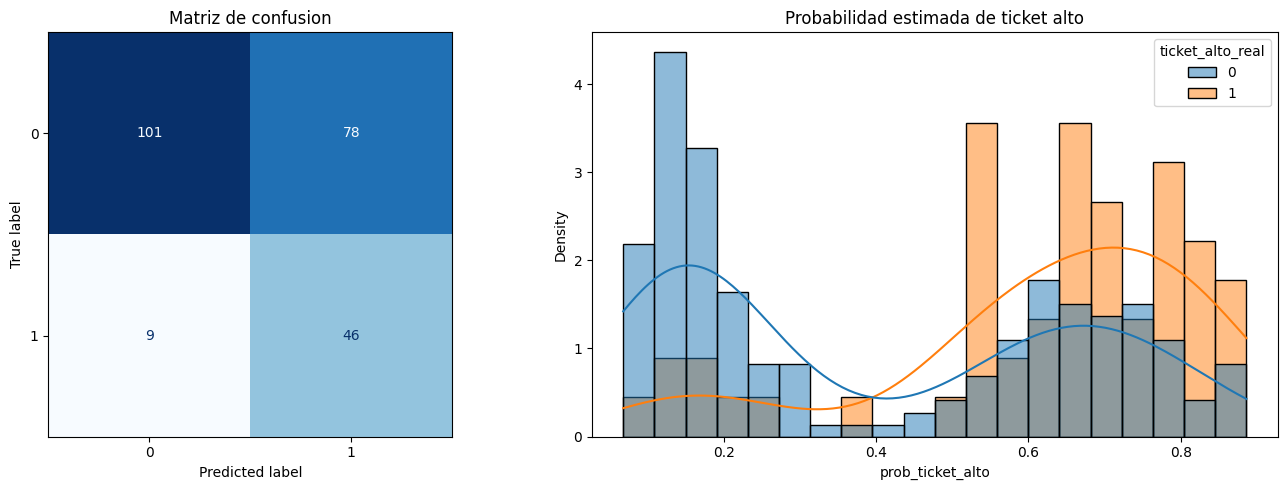

In [7]:
# Construir una vista rapida de resultados sobre test.
resultados_test = X_test.copy()
resultados_test["ticket_alto_real"] = y_test
resultados_test["ticket_alto_pred"] = y_pred
resultados_test["prob_ticket_alto"] = y_prob

# Graficar la matriz de confusión y la distribución de probabilidades.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión")

sns.histplot(
    data=resultados_test,
    x="prob_ticket_alto",
    hue="ticket_alto_real",
    bins=20,
    kde=True,
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Probabilidad estimada de ticket alto")
axes[1].set_xlabel("prob_ticket_alto")
plt.tight_layout()


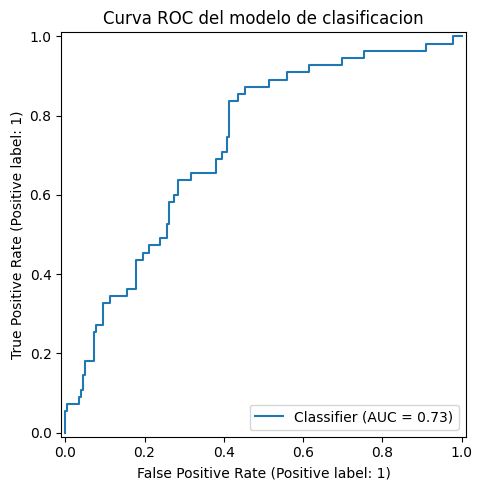

In [8]:
# Graficar la curva ROC del modelo.
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
ax.set_title("Curva ROC del modelo de clasificación")
plt.tight_layout()


### Resultado

Las visualizaciones permiten revisar el comportamiento del clasificador sobre el conjunto de prueba.

En la **matriz de confusión**:

- la fila `0` representa tickets normales reales
- la fila `1` representa tickets altos reales
- la columna `0` indica que el modelo predijo ticket normal
- la columna `1` indica que el modelo predijo ticket alto

Con esa lectura, los conteos observados fueron:

- verdaderos negativos: `101`
- falsos positivos: `78`
- falsos negativos: `9`
- verdaderos positivos: `46`

Esto muestra que el modelo detecta muchos tickets altos reales y comete pocos falsos negativos, pero al mismo tiempo marca como altos varios tickets que en realidad eran normales.

En la **gráfica de probabilidad estimada de ticket alto**, el eje horizontal muestra la probabilidad que asígna el modelo a la clase `ticket_alto`. Las barras azules corresponden a tickets normales reales y las naranjas a tickets altos reales. Se observa que los tickets normales tienden a concentrarse en probabilidades bajas, mientras que los tickets altos aparecen con mayor frecuencia en probabilidades medias y altas. Donde ambas distribuciónes se traslapan es donde el modelo tiene más dificultad para separar las clases.

Además, la **curva ROC** muestra un `AUC` cercano a `0.73`, lo cual es consistente con la tabla de métricas y confirma que el modelo sí logra separar en cierta medida ambas clases.


## 8. Exportar el parquet final del modelo


In [9]:
# Crear carpetas de salida para la etapa 03.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Entrenar el modelo final con toda la base disponible.
# Aquí ya no se usa solo la partición de entrenamiento, sino la base completa de la etapa 02.
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced")),
])
final_pipeline.fit(X, y)

# Generar la salida final con predicciones y probabilidades por ticket.
df_predictions = df.copy()
df_predictions["pred_ticket_alto"] = final_pipeline.predict(X)
df_predictions["prob_ticket_alto"] = final_pipeline.predict_proba(X)[:, 1]
df_predictions["modelo"] = "Regresion Logística"
df_predictions["fuente_parquet"] = "02_base_eda_tickets.parquet"
df_predictions["conjunto_evaluacion"] = "train"
df_predictions.loc[idx_test, "conjunto_evaluacion"] = "test"

# Unir a la salida final las predicciones observadas sobre test para poder revisarlas despues.
test_lookup = pd.DataFrame(
    {
        "idx": idx_test,
        "pred_ticket_alto_test": y_pred,
        "prob_ticket_alto_test": y_prob,
    }
).set_index("idx")

df_predictions = df_predictions.join(test_lookup, how="left")

# Exportar el parquet final y los artefactos técnicos del modelo.
df_predictions.to_parquet(OUTPUT_PATH, index=False)
joblib.dump(final_pipeline, MODEL_PATH)
FEATURES_PATH.write_text(json.dumps(FEATURES, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Parquet generado en: {OUTPUT_PATH}")
print(f"Modelo guardado en: {MODEL_PATH}")


Parquet generado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\parquets\03_Modelo_Clasificacion_Ticket_Alto\03_tickets_clasificados.parquet
Modelo guardado en: D:\08_Octavo semestre La Salle\Desarrollo De Inteligencia De Negocios\PROYECTO Maching learing\Capa Machine Learning\models\03_Modelo_Clasificacion_Ticket_Alto\03_modelo_regresion_logistica.joblib


In [10]:
# Verificar la salida exportada de la etapa 03.
df_exportado = pd.read_parquet(OUTPUT_PATH)
df_exportado.shape


(1167, 50)

### Resultado

El parquet final de clasificación se genero correctamente en la carpeta `parquets/03_Modelo_Clasificacion_Ticket_Alto`.

También se guardo el modelo entrenado en la carpeta `models/03_Modelo_Clasificacion_Ticket_Alto`.

Después de volver a leer la salida exportada, se confirmó que el archivo final conserva una estructura de:

- `1167 filas`
- `50 columnas`

La salida final incluye, entre otras columnas nuevas, `pred_ticket_alto`, `prob_ticket_alto`, `modelo`, `fuente_parquet` y `conjunto_evaluacion`.

Con esto, la etapa `03` queda cerrada con una salida que ya incluye la clase predicha, la probabilidad estimada y la marca de conjunto de evaluación para cada ticket.


## Conclusión

La etapa `03` entrena una regresión logística para clasificar `ticket_alto` y genera `03_tickets_clasificados.parquet` con `1167 filas` y `50 columnas`. El modelo alcanza `accuracy = 0.6282` y `roc_auc = 0.7278`, por lo que ya ofrece una separación útil entre tickets normales y tickets altos.
